<a href="https://colab.research.google.com/github/PriyaVerma06/EDA-IPL/blob/fix-E3/fix_E3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

issue #8


In [1]:
# 1. Setup and Imports

import pandas as pd
import matplotlib.pyplot as plt


In [3]:
# 2. Load Data

df = pd.read_csv("https://raw.githubusercontent.com/PriyaVerma06/EDA-IPL/main/data/matches.csv")

In [4]:
# 3. Toss Impact Analysis

# Matches where toss winner = match winner
toss_win_matches = df[df["toss_winner"] == df["winner"]]

toss_win_percentage = (len(toss_win_matches) / len(df)) * 100

print("Toss Win Match Win %:", round(toss_win_percentage, 2))

Toss Win Match Win %: 50.59


In [5]:
# 4. Decision Impact

# Create column: did toss winner win match?
df["toss_win_match"] = df["toss_winner"] == df["winner"]

# Group by toss decision
decision_impact = df.groupby("toss_decision")["toss_win_match"].mean() * 100

print("\nWin % based on Toss Decision:")
print(decision_impact)



Win % based on Toss Decision:
toss_decision
bat      45.268542
field    53.551136
Name: toss_win_match, dtype: float64


In [6]:
# 5. Season-wise Analysis

season_decision = df.groupby(["season", "toss_decision"])["toss_win_match"].mean().unstack() * 100

print("\nSeason-wise Decision Impact:")
print(season_decision)


Season-wise Decision Impact:
toss_decision        bat      field
season                             
2007/08        34.615385  59.375000
2009           54.285714  63.636364
2009/10        53.846154  47.619048
2011           44.000000  56.250000
2012           40.540541  48.648649
2013           46.666667  48.387097
2014           31.578947  58.536585
2015           56.000000  41.176471
2016           18.181818  65.306122
2017           54.545455  58.333333
2018           50.000000  54.000000
2019           50.000000  62.000000
2020/21        40.740741  42.424242
2021           43.750000  63.636364
2022           46.666667  49.152542
2023           52.380952  43.396226
2024           36.842105  46.153846


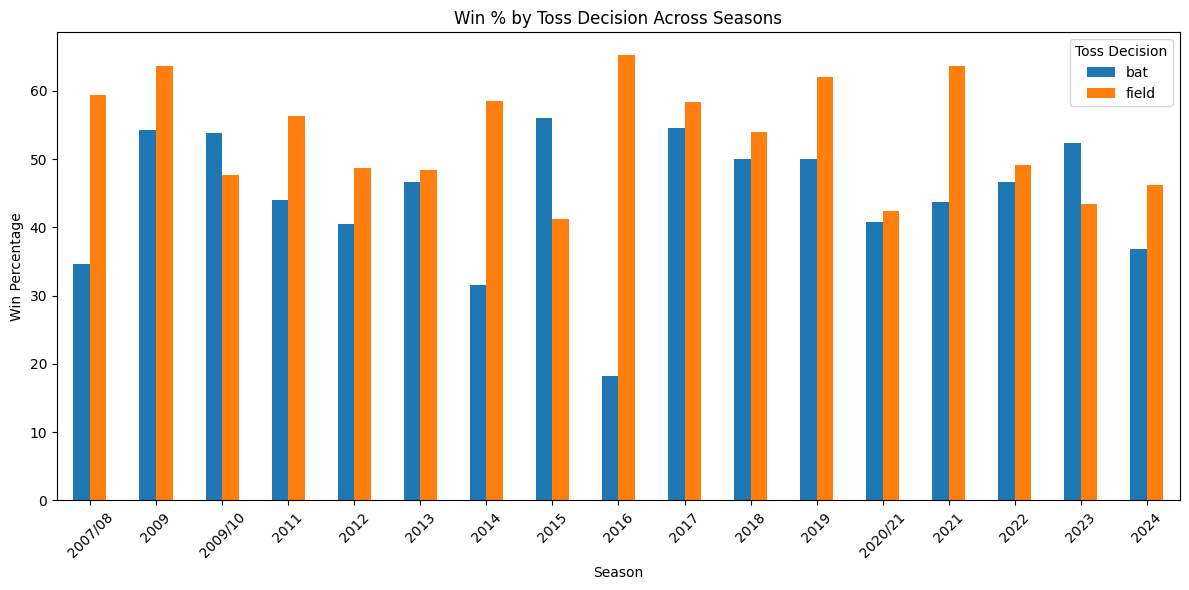

In [7]:
# 6. Visualization

season_decision.plot(kind="bar", figsize=(12,6))

plt.title("Win % by Toss Decision Across Seasons")
plt.xlabel("Season")
plt.ylabel("Win Percentage")
plt.legend(title="Toss Decision")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()